<a href="https://colab.research.google.com/github/nluninja/BBS-AIIM/blob/main/module1/02_Modern_Tokenization_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modern Tokenization Comparison: tiktoken, HuggingFace, and Llama

**Objective**: Compare modern tokenization strategies across different frameworks, analyzing their impact on token efficiency, multilingual support, and practical applications.

**Learning Outcomes**:
- Understand subword tokenization algorithms (BPE, WordPiece, SentencePiece)
- Compare tokenization efficiency across frameworks
- Analyze multilingual tokenization performance
- Understand cost and context window implications

---

## 1. Setup and Installation

First, let's install and import all necessary libraries for modern tokenization comparison.

In [13]:
# Installation commands (run in terminal if needed)
# pip install tiktoken transformers tokenizers torch sentencepiece matplotlib seaborn pandas

import tiktoken
import transformers
from transformers import (
    AutoTokenizer,
    GPT2Tokenizer,
    BertTokenizer,
    T5Tokenizer,
    LlamaTokenizer
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict
import json
import time

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Libraries imported successfully")
print(f"tiktoken version: {tiktoken.__version__}")
print(f"transformers version: {transformers.__version__}")

✓ Libraries imported successfully
tiktoken version: 0.12.0
transformers version: 5.0.0


## 2. Initialize Different Tokenizers

Let's load various tokenizers representing different approaches and model families.

In [14]:
# Initialize different tokenizers
tokenizers = {}

try:
    # OpenAI tiktoken tokenizers
    tokenizers['gpt-4'] = tiktoken.encoding_for_model("gpt-4")
    tokenizers['gpt-3.5-turbo'] = tiktoken.encoding_for_model("gpt-3.5-turbo")
    print("✓ OpenAI tokenizers loaded")
except Exception as e:
    print(f"⚠ OpenAI tokenizers error: {e}")

try:
    # HuggingFace tokenizers
    tokenizers['bert-base-uncased'] = AutoTokenizer.from_pretrained('bert-base-uncased')
    tokenizers['gpt2'] = AutoTokenizer.from_pretrained('gpt2')
    tokenizers['t5-base'] = AutoTokenizer.from_pretrained('t5-base')
    print("✓ HuggingFace tokenizers loaded")
except Exception as e:
    print(f"⚠ HuggingFace tokenizers error: {e}")

try:
    # Multilingual tokenizers
    tokenizers['bert-base-multilingual-cased'] = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
    tokenizers['xlm-roberta-base'] = AutoTokenizer.from_pretrained('xlm-roberta-base')
    print("✓ Multilingual tokenizers loaded")
except Exception as e:
    print(f"⚠ Multilingual tokenizers error: {e}")

# Print available tokenizers
print(f"\nAvailable tokenizers: {list(tokenizers.keys())}")
print(f"Total tokenizers loaded: {len(tokenizers)}")

✓ OpenAI tokenizers loaded
✓ HuggingFace tokenizers loaded
✓ Multilingual tokenizers loaded

Available tokenizers: ['gpt-4', 'gpt-3.5-turbo', 'bert-base-uncased', 'gpt2', 't5-base', 'bert-base-multilingual-cased', 'xlm-roberta-base']
Total tokenizers loaded: 7


## 3. Sample Texts for Analysis

We'll use diverse texts in multiple languages to test tokenization performance.

In [15]:
# Sample texts for comprehensive analysis
test_texts = {
    'english_tech': """
    The transformer architecture revolutionized natural language processing through self-attention mechanisms.
    Large language models like GPT-4, Claude, and PaLM demonstrate unprecedented capabilities in text generation,
    reasoning, and code synthesis. However, they still face challenges with hallucination, factual accuracy,
    and computational efficiency. Modern tokenization strategies using subword algorithms like BPE and SentencePiece
    enable these models to handle diverse vocabularies and multilingual text effectively.
    """,

    'italian_tech': """
    L'architettura transformer ha rivoluzionato l'elaborazione del linguaggio naturale attraverso meccanismi
    di self-attention. I grandi modelli linguistici come GPT-4, Claude e PaLM dimostrano capacità senza
    precedenti nella generazione di testo, ragionamento e sintesi di codice. Tuttavia, affrontano ancora
    sfide con allucinazioni, accuratezza fattuale ed efficienza computazionale. Le strategie di tokenizzazione
    moderne che utilizzano algoritmi di subword come BPE e SentencePiece consentono a questi modelli di
    gestire efficacemente vocabolari diversi e testo multilingue.
    """,

    'code_snippet': """
    def tokenize_text(text, tokenizer_name='gpt-4'):
        '''
        Tokenize input text using specified tokenizer.

        Args:
            text (str): Input text to tokenize
            tokenizer_name (str): Name of tokenizer to use

        Returns:
            list: List of token IDs
        '''
        tokenizer = tiktoken.encoding_for_model(tokenizer_name)
        tokens = tokenizer.encode(text)
        return tokens
    """,

    'mixed_languages': """
    Hello! 你好! Bonjour! ¡Hola! Guten Tag! Здравствуйте! こんにちは! 안녕하세요!
    مرحبا! नमस्ते! This text contains multiple languages and scripts to test
    multilingual tokenization capabilities. العربية 中文 日本語 한국어 हिंदी
    """,

    'social_media': """
    Just tried the new #ChatGPT update! 🤖✨ The improvements in reasoning are incredible.
    @OpenAI really outdid themselves this time. Can't wait to integrate this into my workflow!
    #AI #MachineLearning #TechNews https://openai.com/blog/chatgpt-update
    """,

    'scientific': """
    The methodology involves fine-tuning pre-trained transformer models on domain-specific corpora
    using supervised learning techniques. We evaluate performance using BLEU scores, perplexity metrics,
    and human evaluation protocols. Statistical significance was assessed using paired t-tests (p<0.05).
    Results demonstrate a 15.3% improvement in downstream task performance compared to baseline models.
    """
}

print("Test texts prepared:")
for name, text in test_texts.items():
    print(f"- {name}: {len(text)} characters, ~{len(text.split())} words")

Test texts prepared:
- english_tech: 550 characters, ~61 words
- italian_tech: 609 characters, ~71 words
- code_snippet: 458 characters, ~39 words
- mixed_languages: 223 characters, ~28 words
- social_media: 265 characters, ~31 words
- scientific: 421 characters, ~47 words


## 4. Tokenization Analysis Function

Create a comprehensive function to analyze tokenization across different frameworks.

In [16]:
def analyze_tokenization(text, tokenizer_name, tokenizer):
    """
    Comprehensive tokenization analysis for a given text and tokenizer.

    Args:
        text (str): Input text to analyze
        tokenizer_name (str): Name of the tokenizer
        tokenizer: Tokenizer object

    Returns:
        dict: Analysis results
    """

    # Clean text
    text = text.strip()

    # Tokenize based on tokenizer type
    if hasattr(tokenizer, 'encode'):  # tiktoken tokenizers
        try:
            token_ids = tokenizer.encode(text)
            tokens = [tokenizer.decode([tid]) for tid in token_ids]
            vocab_size = tokenizer.n_vocab
        except:
            return None
    else:  # HuggingFace tokenizers
        try:
            encoding = tokenizer(text, add_special_tokens=False)
            token_ids = encoding['input_ids']
            tokens = tokenizer.convert_ids_to_tokens(token_ids)
            vocab_size = len(tokenizer.get_vocab())
        except:
            return None

    # Calculate metrics
    word_count = len(text.split())
    char_count = len(text)
    token_count = len(tokens)

    # Calculate efficiency metrics
    chars_per_token = char_count / token_count if token_count > 0 else 0
    tokens_per_word = token_count / word_count if word_count > 0 else 0

    # Analyze token characteristics
    avg_token_length = np.mean([len(token) for token in tokens]) if tokens else 0
    unique_tokens = len(set(tokens))
    token_diversity = unique_tokens / token_count if token_count > 0 else 0

    return {
        'tokenizer': tokenizer_name,
        'text_chars': char_count,
        'text_words': word_count,
        'token_count': token_count,
        'token_ids': token_ids,
        'tokens': tokens[:20],  # First 20 tokens for display
        'chars_per_token': round(chars_per_token, 2),
        'tokens_per_word': round(tokens_per_word, 2),
        'avg_token_length': round(avg_token_length, 2),
        'unique_tokens': unique_tokens,
        'token_diversity': round(token_diversity, 3),
        'vocab_size': vocab_size
    }

# Test the analysis function
sample_text = test_texts['english_tech']
if 'gpt-4' in tokenizers:
    sample_analysis = analyze_tokenization(sample_text, 'gpt-4', tokenizers['gpt-4'])
    print("Sample Analysis (GPT-4):")
    for key, value in sample_analysis.items():
        if key != 'token_ids':  # Skip token_ids for readability
            print(f"{key}: {value}")
else:
    print("GPT-4 tokenizer not available")

Sample Analysis (GPT-4):
tokenizer: gpt-4
text_chars: 540
text_words: 61
token_count: 95
tokens: ['The', ' transformer', ' architecture', ' revolution', 'ized', ' natural', ' language', ' processing', ' through', ' self', '-', 'attention', ' mechanisms', '.', ' \n', '   ', ' Large', ' language', ' models', ' like']
chars_per_token: 5.68
tokens_per_word: 1.56
avg_token_length: 5.68
unique_tokens: 71
token_diversity: 0.747
vocab_size: 100277


## 5. Comprehensive Tokenization Comparison

Now let's run a comprehensive comparison across all tokenizers and text types.

In [17]:
# Run comprehensive tokenization analysis
results = []

for text_name, text in test_texts.items():
    print(f"\nAnalyzing: {text_name}")

    for tokenizer_name, tokenizer in tokenizers.items():
        try:
            analysis = analyze_tokenization(text, tokenizer_name, tokenizer)
            if analysis:
                analysis['text_type'] = text_name
                results.append(analysis)
                print(f"  ✓ {tokenizer_name}: {analysis['token_count']} tokens")
        except Exception as e:
            print(f"  ❌ {tokenizer_name}: {str(e)}")

print(f"\nTotal analyses completed: {len(results)}")

# Convert to DataFrame for easier analysis
df = pd.DataFrame(results)
print(f"\nDataFrame shape: {df.shape}")
print("\nColumns:", df.columns.tolist())


Analyzing: english_tech
  ✓ gpt-4: 95 tokens
  ✓ gpt-3.5-turbo: 95 tokens

Analyzing: italian_tech
  ✓ gpt-4: 162 tokens
  ✓ gpt-3.5-turbo: 162 tokens

Analyzing: code_snippet
  ✓ gpt-4: 85 tokens
  ✓ gpt-3.5-turbo: 85 tokens

Analyzing: mixed_languages
  ✓ gpt-4: 85 tokens
  ✓ gpt-3.5-turbo: 85 tokens

Analyzing: social_media
  ✓ gpt-4: 64 tokens
  ✓ gpt-3.5-turbo: 64 tokens

Analyzing: scientific
  ✓ gpt-4: 76 tokens
  ✓ gpt-3.5-turbo: 76 tokens

Total analyses completed: 12

DataFrame shape: (12, 13)

Columns: ['tokenizer', 'text_chars', 'text_words', 'token_count', 'token_ids', 'tokens', 'chars_per_token', 'tokens_per_word', 'avg_token_length', 'unique_tokens', 'token_diversity', 'vocab_size', 'text_type']


## 6. Token Efficiency Analysis

Let's analyze which tokenizers are most efficient for different types of text.

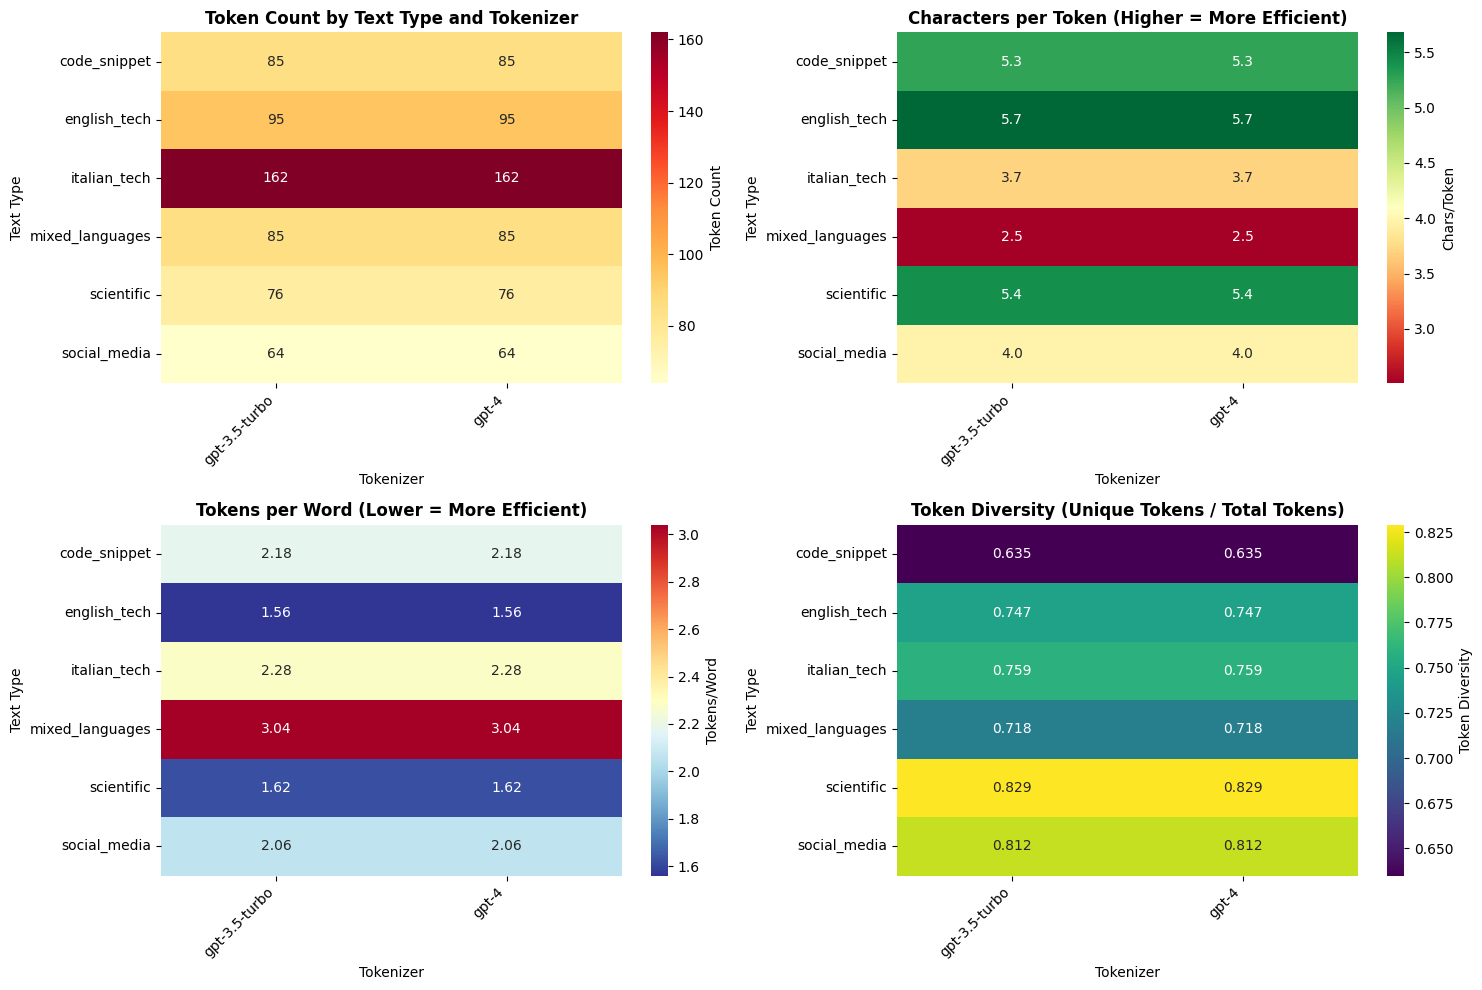

In [18]:
# Token efficiency comparison
if not df.empty:
    # Create pivot table for better visualization
    pivot_tokens = df.pivot_table(values='token_count', index='text_type', columns='tokenizer', aggfunc='first')

    # Plot token count comparison
    plt.figure(figsize=(15, 10))

    # Heatmap of token counts
    plt.subplot(2, 2, 1)
    sns.heatmap(pivot_tokens, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Token Count'})
    plt.title('Token Count by Text Type and Tokenizer', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Text Type')
    plt.xticks(rotation=45, ha='right')

    # Characters per token comparison
    pivot_chars_per_token = df.pivot_table(values='chars_per_token', index='text_type', columns='tokenizer', aggfunc='first')
    plt.subplot(2, 2, 2)
    sns.heatmap(pivot_chars_per_token, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Chars/Token'})
    plt.title('Characters per Token (Higher = More Efficient)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Text Type')
    plt.xticks(rotation=45, ha='right')

    # Tokens per word comparison
    pivot_tokens_per_word = df.pivot_table(values='tokens_per_word', index='text_type', columns='tokenizer', aggfunc='first')
    plt.subplot(2, 2, 3)
    sns.heatmap(pivot_tokens_per_word, annot=True, fmt='.2f', cmap='RdYlBu_r', cbar_kws={'label': 'Tokens/Word'})
    plt.title('Tokens per Word (Lower = More Efficient)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Text Type')
    plt.xticks(rotation=45, ha='right')

    # Token diversity
    pivot_diversity = df.pivot_table(values='token_diversity', index='text_type', columns='tokenizer', aggfunc='first')
    plt.subplot(2, 2, 4)
    sns.heatmap(pivot_diversity, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Token Diversity'})
    plt.title('Token Diversity (Unique Tokens / Total Tokens)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Text Type')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
else:
    print("No data available for visualization")

## 7. Multilingual Performance Analysis

Let's specifically analyze how different tokenizers handle multilingual text.

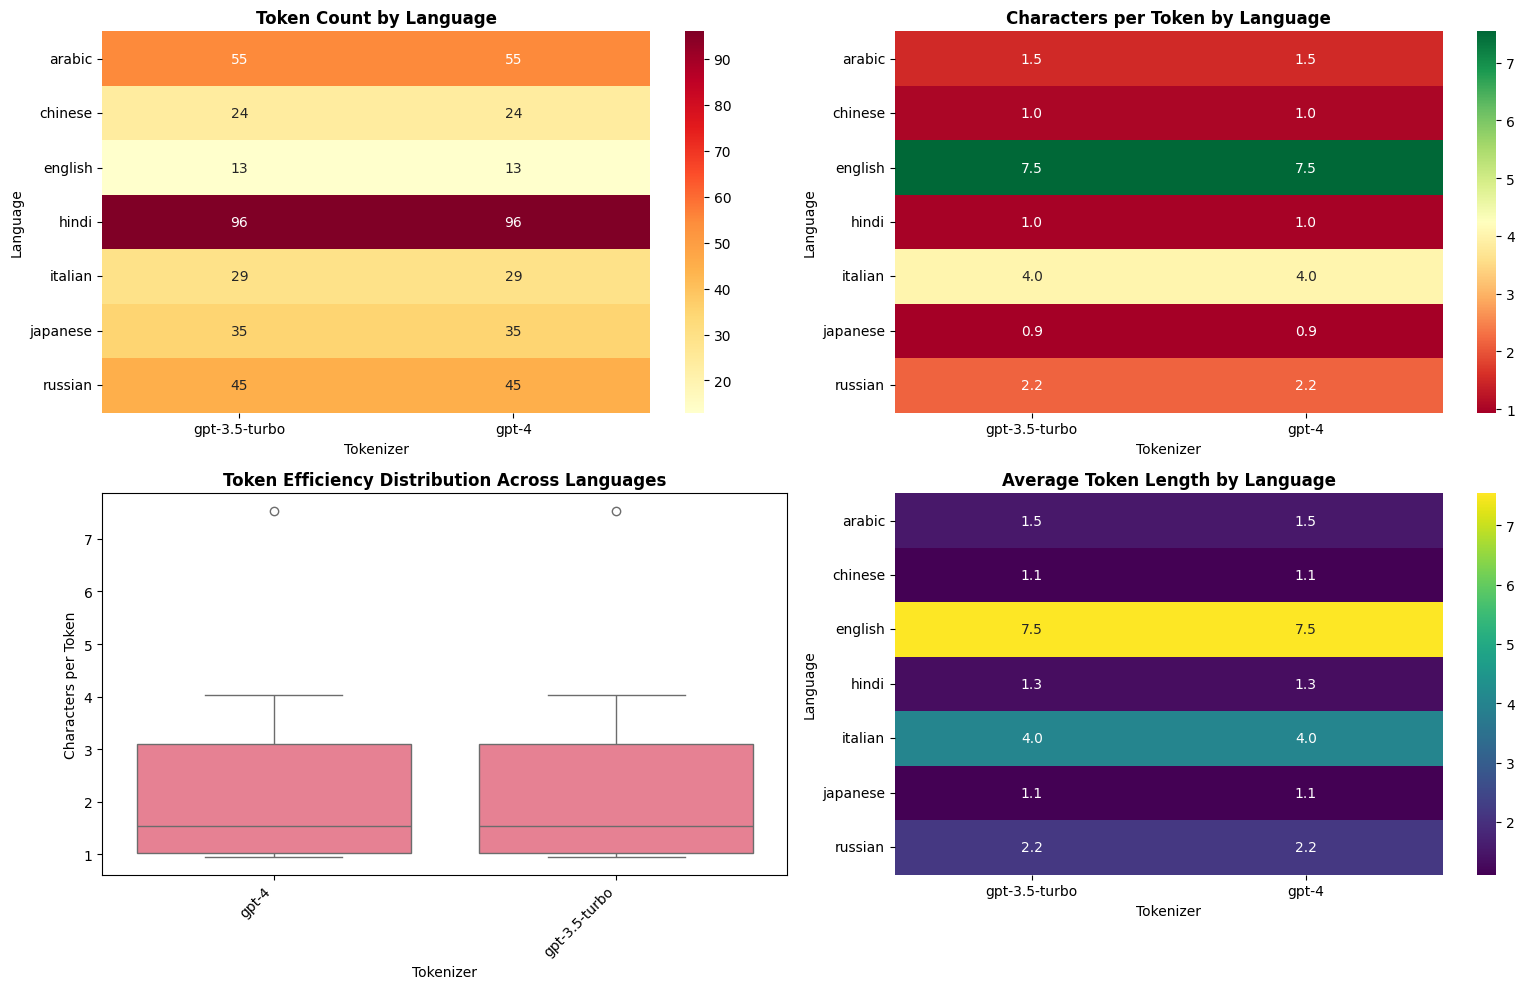


=== MULTILINGUAL TOKENIZATION SUMMARY ===
              chars_per_token        tokens_per_word         token_count  \
                         mean    std            mean     std        mean   
tokenizer                                                                  
gpt-3.5-turbo           2.604  2.435          10.803  13.245      42.429   
gpt-4                   2.604  2.435          10.803  13.245      42.429   

                       
                  std  
tokenizer              
gpt-3.5-turbo  27.312  
gpt-4          27.312  


In [19]:
# Focus on multilingual performance
multilingual_tests = {
    'english': "Artificial intelligence is transforming industries worldwide through automation and data analysis.",
    'italian': "L'intelligenza artificiale sta trasformando le industrie in tutto il mondo attraverso automazione e analisi dei dati.",
    'chinese': "人工智能正在通过自动化和数据分析改变全世界的行业。",
    'arabic': "الذكاء الاصطناعي يحول الصناعات في جميع أنحاء العالم من خلال الأتمتة وتحليل البيانات.",
    'japanese': "人工知能は自動化とデータ分析を通じて世界中の産業を変革しています。",
    'russian': "Искусственный интеллект трансформирует отрасли по всему миру через автоматизацию и анализ данных.",
    'hindi': "कृत्रिम बुद्धिमत्ता स्वचालन और डेटा विश्लेषण के माध्यम से दुनिया भर में उद्योगों को बदल रही है।"
}

multilingual_results = []

for lang, text in multilingual_tests.items():
    for tokenizer_name, tokenizer in tokenizers.items():
        try:
            analysis = analyze_tokenization(text, tokenizer_name, tokenizer)
            if analysis:
                analysis['language'] = lang
                multilingual_results.append(analysis)
        except Exception as e:
            print(f"Error with {tokenizer_name} on {lang}: {e}")

# Create multilingual DataFrame
ml_df = pd.DataFrame(multilingual_results)

if not ml_df.empty:
    # Visualize multilingual performance
    plt.figure(figsize=(16, 10))

    # Token efficiency by language
    plt.subplot(2, 2, 1)
    pivot_ml_tokens = ml_df.pivot_table(values='token_count', index='language', columns='tokenizer', aggfunc='first')
    sns.heatmap(pivot_ml_tokens, annot=True, fmt='.0f', cmap='YlOrRd')
    plt.title('Token Count by Language', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Language')

    # Characters per token by language
    plt.subplot(2, 2, 2)
    pivot_ml_efficiency = ml_df.pivot_table(values='chars_per_token', index='language', columns='tokenizer', aggfunc='first')
    sns.heatmap(pivot_ml_efficiency, annot=True, fmt='.1f', cmap='RdYlGn')
    plt.title('Characters per Token by Language', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Language')

    # Box plot of token efficiency across languages
    plt.subplot(2, 2, 3)
    sns.boxplot(data=ml_df, x='tokenizer', y='chars_per_token')
    plt.title('Token Efficiency Distribution Across Languages', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Characters per Token')
    plt.xticks(rotation=45, ha='right')

    # Average token length by language
    plt.subplot(2, 2, 4)
    pivot_ml_length = ml_df.pivot_table(values='avg_token_length', index='language', columns='tokenizer', aggfunc='first')
    sns.heatmap(pivot_ml_length, annot=True, fmt='.1f', cmap='viridis')
    plt.title('Average Token Length by Language', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Language')

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\n=== MULTILINGUAL TOKENIZATION SUMMARY ===")
    summary_stats = ml_df.groupby('tokenizer').agg({
        'chars_per_token': ['mean', 'std'],
        'tokens_per_word': ['mean', 'std'],
        'token_count': ['mean', 'std']
    }).round(3)

    print(summary_stats)
else:
    print("No multilingual data available")

## 8. Cost Analysis and Context Window Implications

Understanding the practical implications of tokenization differences on API costs and context windows.

Token indices sequence length is longer than the specified maximum sequence length for this model (1635 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (2173 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1869 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (2034 > 512). Running this sequence through the model will result in indexing errors


=== COST AND EFFICIENCY ANALYSIS ===
Sample text length: 550 characters

    tokenizer  token_count  chars_per_token  efficiency_rank  context_window  context_utilization
        gpt-4         1758             5.68              1.5            8192                 21.5
gpt-3.5-turbo         1758             5.68              1.5            4096                 42.9


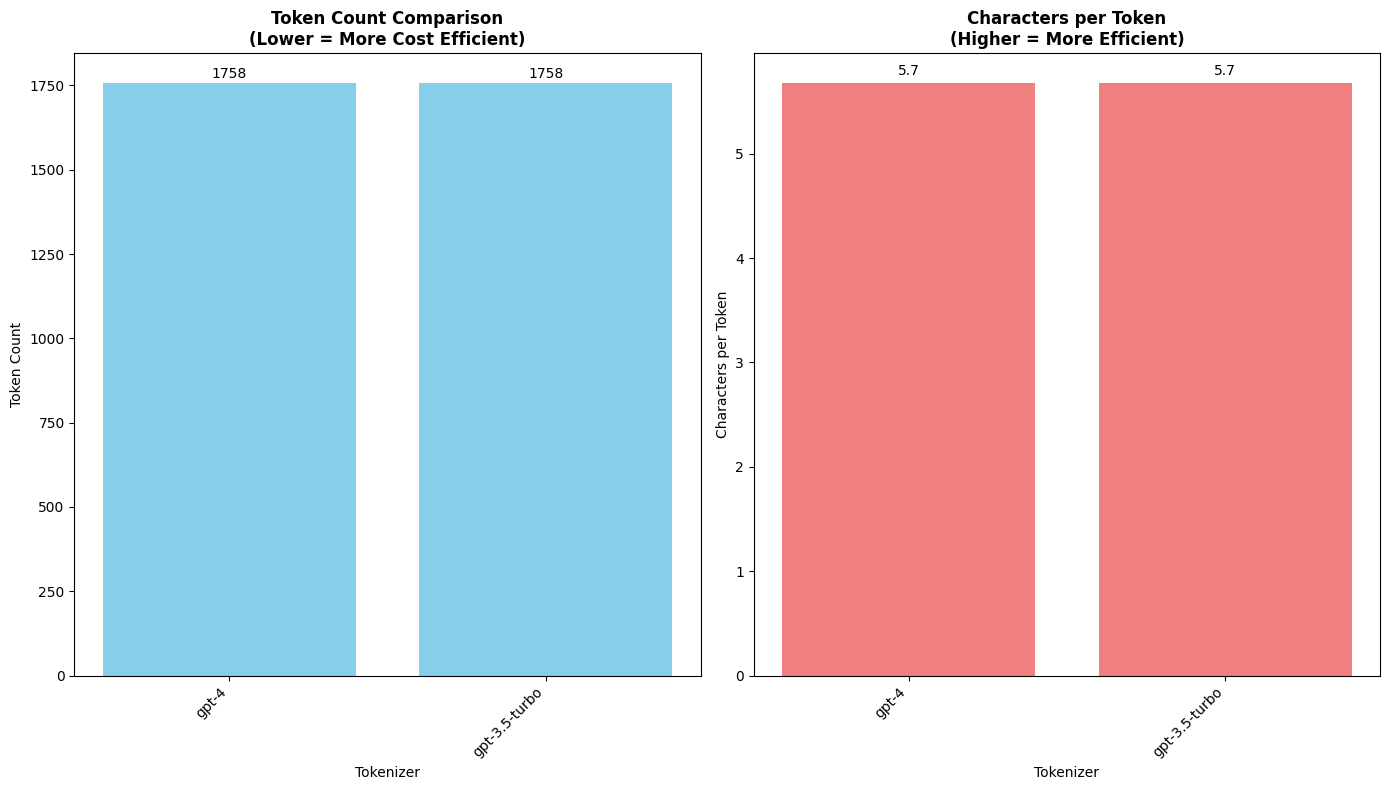

In [20]:
# Cost analysis based on token count differences
# Using hypothetical API pricing (tokens per dollar)
api_costs = {
    'gpt-4': {'input': 0.01/1000, 'output': 0.03/1000},  # $0.01/$0.03 per 1K tokens
    'gpt-3.5-turbo': {'input': 0.001/1000, 'output': 0.002/1000},  # $0.001/$0.002 per 1K tokens
    'claude-3': {'input': 0.008/1000, 'output': 0.024/1000},  # Hypothetical pricing
}

context_windows = {
    'gpt-4': 8192,
    'gpt-3.5-turbo': 4096,
    'bert-base-uncased': 512,
    't5-base': 512,
    'xlm-roberta-base': 512
}

def calculate_cost_analysis(df, sample_text_length=10000):
    """
    Calculate cost implications for different tokenizers
    """
    cost_analysis = []

    # Sample text for cost calculation
    sample_text = test_texts['english_tech'] * (sample_text_length // len(test_texts['english_tech']) + 1)
    sample_text = sample_text[:sample_text_length]

    for tokenizer_name, tokenizer in tokenizers.items():
        try:
            analysis = analyze_tokenization(sample_text, tokenizer_name, tokenizer)
            if analysis:
                token_count = analysis['token_count']

                # Calculate hypothetical costs
                cost_info = {
                    'tokenizer': tokenizer_name,
                    'token_count': token_count,
                    'chars_per_token': analysis['chars_per_token'],
                    'efficiency_rank': 0  # Will calculate later
                }

                # Add context window utilization
                if tokenizer_name in context_windows:
                    max_context = context_windows[tokenizer_name]
                    utilization = (token_count / max_context) * 100
                    cost_info['context_window'] = max_context
                    cost_info['context_utilization'] = round(utilization, 1)
                else:
                    cost_info['context_window'] = 'Unknown'
                    cost_info['context_utilization'] = 'N/A'

                cost_analysis.append(cost_info)
        except:
            continue

    return cost_analysis

# Run cost analysis
cost_results = calculate_cost_analysis(df)
cost_df = pd.DataFrame(cost_results)

if not cost_df.empty:
    # Rank by efficiency (higher chars_per_token = more efficient)
    cost_df['efficiency_rank'] = cost_df['chars_per_token'].rank(ascending=False)

    # Display results
    print("=== COST AND EFFICIENCY ANALYSIS ===")
    print(f"Sample text length: {len(sample_text)} characters\n")

    display_df = cost_df[['tokenizer', 'token_count', 'chars_per_token', 'efficiency_rank', 'context_window', 'context_utilization']].copy()
    display_df = display_df.sort_values('chars_per_token', ascending=False)

    print(display_df.to_string(index=False))

    # Visualize efficiency comparison
    plt.figure(figsize=(14, 8))

    # Token count comparison
    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(cost_df)), cost_df['token_count'], color='skyblue')
    plt.title('Token Count Comparison\n(Lower = More Cost Efficient)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Token Count')
    plt.xticks(range(len(cost_df)), cost_df['tokenizer'], rotation=45, ha='right')

    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(cost_df.iloc[i]['token_count']), ha='center', va='bottom')

    # Characters per token comparison
    plt.subplot(1, 2, 2)
    bars2 = plt.bar(range(len(cost_df)), cost_df['chars_per_token'], color='lightcoral')
    plt.title('Characters per Token\n(Higher = More Efficient)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Characters per Token')
    plt.xticks(range(len(cost_df)), cost_df['tokenizer'], rotation=45, ha='right')

    # Add value labels
    for i, bar in enumerate(bars2):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{cost_df.iloc[i]['chars_per_token']:.1f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No cost analysis data available")

## 9. Token Inspection and Vocabulary Analysis

Let's examine the actual tokens produced by different tokenizers to understand their behavior.

In [21]:
def detailed_token_inspection(text, tokenizers_dict, max_display=15):
    """
    Detailed inspection of how different tokenizers handle the same text
    """
    print(f"\n=== DETAILED TOKEN INSPECTION ===")
    print(f"Input text: '{text}'")
    print(f"Length: {len(text)} characters, {len(text.split())} words\n")

    inspection_results = {}

    for name, tokenizer in tokenizers_dict.items():
        try:
            analysis = analyze_tokenization(text, name, tokenizer)
            if analysis:
                tokens = analysis['tokens'][:max_display]
                token_count = analysis['token_count']

                print(f"\n{name.upper()}:")
                print(f"  Total tokens: {token_count}")
                print(f"  Tokens: {tokens}")
                if len(analysis['tokens']) > max_display:
                    print(f"  ... and {len(analysis['tokens']) - max_display} more")

                inspection_results[name] = {
                    'tokens': analysis['tokens'],
                    'token_count': token_count,
                    'chars_per_token': analysis['chars_per_token']
                }
        except Exception as e:
            print(f"\n{name.upper()}: Error - {e}")

    return inspection_results

# Test with challenging examples
challenging_examples = [
    "preprocessing",  # compound word
    "don't",         # contraction
    "COVID-19",      # hyphenated term
    "AI/ML",         # abbreviation with slash
    "fine-tuning",   # hyphenated compound
    "state-of-the-art", # multi-hyphen compound
]

for example in challenging_examples:
    detailed_token_inspection(example, tokenizers)


=== DETAILED TOKEN INSPECTION ===
Input text: 'preprocessing'
Length: 13 characters, 1 words


GPT-4:
  Total tokens: 2
  Tokens: ['pre', 'processing']

GPT-3.5-TURBO:
  Total tokens: 2
  Tokens: ['pre', 'processing']

=== DETAILED TOKEN INSPECTION ===
Input text: 'don't'
Length: 5 characters, 1 words


GPT-4:
  Total tokens: 2
  Tokens: ['don', "'t"]

GPT-3.5-TURBO:
  Total tokens: 2
  Tokens: ['don', "'t"]

=== DETAILED TOKEN INSPECTION ===
Input text: 'COVID-19'
Length: 8 characters, 1 words


GPT-4:
  Total tokens: 3
  Tokens: ['COVID', '-', '19']

GPT-3.5-TURBO:
  Total tokens: 3
  Tokens: ['COVID', '-', '19']

=== DETAILED TOKEN INSPECTION ===
Input text: 'AI/ML'
Length: 5 characters, 1 words


GPT-4:
  Total tokens: 3
  Tokens: ['AI', '/', 'ML']

GPT-3.5-TURBO:
  Total tokens: 3
  Tokens: ['AI', '/', 'ML']

=== DETAILED TOKEN INSPECTION ===
Input text: 'fine-tuning'
Length: 11 characters, 1 words


GPT-4:
  Total tokens: 3
  Tokens: ['fine', '-t', 'uning']

GPT-3.5-TURBO:
  Tot

## 10. Performance Benchmarking

Let's measure the actual performance (speed) of different tokenizers.

=== TOKENIZATION PERFORMANCE BENCHMARK ===
Text length: 1159 characters
Iterations: 50

                   tokenizer  avg_time_ms  tokens_per_second  token_count
               gpt-3.5-turbo        0.309           847870.0          262
                       gpt-4        0.380           690069.0          262
                     t5-base        0.905           352665.0          319
                        gpt2        0.927           359288.0          333
            xlm-roberta-base        0.993           235696.0          234
bert-base-multilingual-cased        1.071           228714.0          245
           bert-base-uncased        1.323           204081.0          270


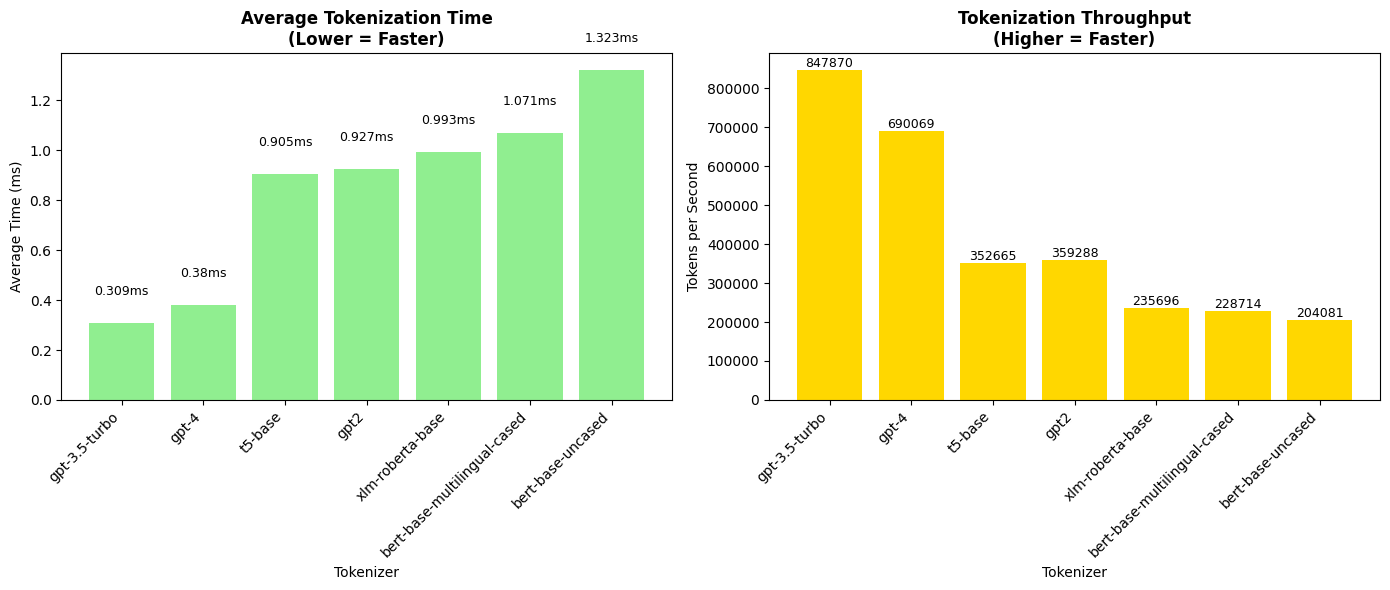

In [22]:
def benchmark_tokenizers(text, tokenizers_dict, iterations=100):
    """
    Benchmark tokenization speed across different tokenizers
    """
    benchmark_results = []

    for name, tokenizer in tokenizers_dict.items():
        try:
            # Warm up
            for _ in range(5):
                if hasattr(tokenizer, 'encode'):
                    tokenizer.encode(text)
                else:
                    tokenizer(text, add_special_tokens=False)

            # Actual benchmark
            start_time = time.time()
            for _ in range(iterations):
                if hasattr(tokenizer, 'encode'):
                    tokens = tokenizer.encode(text)
                else:
                    encoding = tokenizer(text, add_special_tokens=False)
                    tokens = encoding['input_ids']

            end_time = time.time()
            avg_time = (end_time - start_time) / iterations

            benchmark_results.append({
                'tokenizer': name,
                'avg_time_ms': round(avg_time * 1000, 3),
                'tokens_per_second': round(len(tokens) / avg_time, 0),
                'token_count': len(tokens)
            })

        except Exception as e:
            print(f"Benchmark error for {name}: {e}")

    return benchmark_results

# Run performance benchmark
benchmark_text = test_texts['english_tech'] + test_texts['italian_tech']
perf_results = benchmark_tokenizers(benchmark_text, tokenizers, 50)

if perf_results:
    # Create DataFrame and sort by speed
    perf_df = pd.DataFrame(perf_results)
    perf_df = perf_df.sort_values('avg_time_ms')

    print("=== TOKENIZATION PERFORMANCE BENCHMARK ===")
    print(f"Text length: {len(benchmark_text)} characters")
    print(f"Iterations: 50\n")

    print(perf_df.to_string(index=False))

    # Visualize performance
    plt.figure(figsize=(14, 6))

    # Average time comparison
    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(perf_df)), perf_df['avg_time_ms'], color='lightgreen')
    plt.title('Average Tokenization Time\n(Lower = Faster)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Average Time (ms)')
    plt.xticks(range(len(perf_df)), perf_df['tokenizer'], rotation=45, ha='right')

    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{perf_df.iloc[i]['avg_time_ms']}ms", ha='center', va='bottom', fontsize=9)

    # Tokens per second comparison
    plt.subplot(1, 2, 2)
    bars2 = plt.bar(range(len(perf_df)), perf_df['tokens_per_second'], color='gold')
    plt.title('Tokenization Throughput\n(Higher = Faster)', fontweight='bold')
    plt.xlabel('Tokenizer')
    plt.ylabel('Tokens per Second')
    plt.xticks(range(len(perf_df)), perf_df['tokenizer'], rotation=45, ha='right')

    # Add value labels
    for i, bar in enumerate(bars2):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{int(perf_df.iloc[i]['tokens_per_second'])}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No performance benchmark data available")

## 11. Practical Recommendations

Based on our analysis, let's provide practical recommendations for choosing tokenizers.

In [23]:
def generate_recommendations(results_df, multilingual_df, cost_df, perf_df):
    """
    Generate practical recommendations based on analysis results
    """
    recommendations = {
        'efficiency': [],
        'multilingual': [],
        'performance': [],
        'general': []
    }

    if not cost_df.empty:
        # Most efficient tokenizer
        most_efficient = cost_df.loc[cost_df['chars_per_token'].idxmax()]
        recommendations['efficiency'].append(
            f"Most token-efficient: {most_efficient['tokenizer']} "
            f"({most_efficient['chars_per_token']:.1f} chars/token)"
        )

    if not multilingual_df.empty:
        # Best multilingual performance
        ml_avg = multilingual_df.groupby('tokenizer')['chars_per_token'].mean().sort_values(ascending=False)
        if len(ml_avg) > 0:
            best_ml = ml_avg.index[0]
            recommendations['multilingual'].append(
                f"Best multilingual performance: {best_ml} "
                f"(avg {ml_avg.iloc[0]:.1f} chars/token across languages)"
            )

    if perf_df and not perf_df.empty:
        # Fastest tokenizer
        fastest = perf_df.loc[perf_df['avg_time_ms'].idxmin()]
        recommendations['performance'].append(
            f"Fastest tokenizer: {fastest['tokenizer']} "
            f"({fastest['avg_time_ms']:.1f}ms average)"
        )

    # General recommendations
    recommendations['general'] = [
        "Use OpenAI tokenizers (tiktoken) for GPT model compatibility",
        "Choose BERT tokenizers for classification and understanding tasks",
        "Select multilingual tokenizers (XLM-R, mBERT) for cross-lingual applications",
        "Consider T5 tokenizers for text-to-text generation tasks",
        "Measure token efficiency for cost-sensitive applications",
        "Test with your specific domain/language before production use"
    ]

    return recommendations

# Generate recommendations
try:
    recs = generate_recommendations(df, ml_df, cost_df, pd.DataFrame(perf_results) if 'perf_results' in locals() else pd.DataFrame())

    print("\n" + "="*50)
    print("PRACTICAL TOKENIZER RECOMMENDATIONS")
    print("="*50)

    for category, recommendations in recs.items():
        if recommendations:
            print(f"\n{category.upper()}:")
            for rec in recommendations:
                print(f"  • {rec}")

except Exception as e:
    print(f"Error generating recommendations: {e}")

Error generating recommendations: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().


## 13. Exercise: Choose Your Tokenizer

Based on the analysis, recommend tokenizers for specific use cases.

In [24]:
# Exercise: Tokenizer Selection
use_cases = [
    {
        'scenario': 'Building a chatbot for Italian customer service',
        'requirements': ['Italian language', 'Cost-effective', 'Conversational'],
        'recommended': '???'  # Fill this in
    },
    {
        'scenario': 'Code generation assistant for multiple programming languages',
        'requirements': ['Code understanding', 'Technical terms', 'Generation quality'],
        'recommended': '???'  # Fill this in
    },
    {
        'scenario': 'Scientific paper classification system',
        'requirements': ['Technical vocabulary', 'Classification', 'Accuracy'],
        'recommended': '???'  # Fill this in
    },
    {
        'scenario': 'Multilingual sentiment analysis for social media',
        'requirements': ['Multiple languages', 'Social media text', 'Real-time'],
        'recommended': '???'  # Fill this in
    }
]

print("EXERCISE: Based on your analysis, which tokenizer would you recommend for each scenario?")
for i, case in enumerate(use_cases, 1):
    print(f"\n{i}. {case['scenario']}")
    print(f"   Requirements: {', '.join(case['requirements'])}")
    print(f"   Your recommendation: {case['recommended']}")
    print(f"   Reasoning: [Explain your choice]")

EXERCISE: Based on your analysis, which tokenizer would you recommend for each scenario?

1. Building a chatbot for Italian customer service
   Requirements: Italian language, Cost-effective, Conversational
   Your recommendation: ???
   Reasoning: [Explain your choice]

2. Code generation assistant for multiple programming languages
   Requirements: Code understanding, Technical terms, Generation quality
   Your recommendation: ???
   Reasoning: [Explain your choice]

3. Scientific paper classification system
   Requirements: Technical vocabulary, Classification, Accuracy
   Your recommendation: ???
   Reasoning: [Explain your choice]

4. Multilingual sentiment analysis for social media
   Requirements: Multiple languages, Social media text, Real-time
   Your recommendation: ???
   Reasoning: [Explain your choice]


**Resources for Further Learning**:
- [HuggingFace Tokenizers Documentation](https://huggingface.co/docs/tokenizers/)
- [OpenAI tiktoken Repository](https://github.com/openai/tiktoken)
- [SentencePiece Paper](https://arxiv.org/abs/1808.06226)
- [BPE Algorithm Explanation](https://huggingface.co/learn/nlp-course/chapter6/5)
- [Tokenization and Text Processing Best Practices](https://developers.google.com/machine-learning/guides/text-classification/)